In [106]:
import pandas as pand
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

In [107]:
df = pand.read_csv("/kaggle/input/datasets/ketangangal/heart-disease-dataset-uci/HeartDiseaseTrain-Test.csv")
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [108]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [109]:
df.isnull().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

In [110]:
# df.fillna(df.mean(), inplace=True)

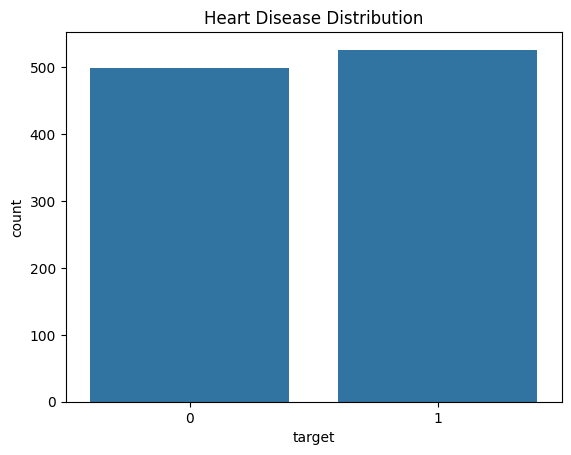

In [111]:
seb.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [112]:
# df['sex'] = df['sex'].map({'Male':1, 'Female':0})
# df['chest_pain_type'] = df['chest_pain_type'].map({'Typical angina':1, })
# plt.figure(figsize=(12,8))
# seb.heatmap(df.corr(), annot=True, cmap='coolwarm')
# plt.title("Feature Correlation")
# plt.show()

In [113]:
for col in df.columns:
    print(f'{col} unique values: {df[col].nunique()}')

age unique values: 41
sex unique values: 2
chest_pain_type unique values: 4
resting_blood_pressure unique values: 49
cholestoral unique values: 152
fasting_blood_sugar unique values: 2
rest_ecg unique values: 3
Max_heart_rate unique values: 91
exercise_induced_angina unique values: 2
oldpeak unique values: 40
slope unique values: 3
vessels_colored_by_flourosopy unique values: 5
thalassemia unique values: 4
target unique values: 2


In [114]:
df = df.rename(columns={
    'age': "Age",
    'sex': "Sex",
    'cp': "Chest Pain Type",
    'trestbps': "Resting BP",
    'chol': "Cholesterol",
    'fbs': "Fasting Blood Sugar",
    'restecg': "Resting ECG",
    'thalach': "Max Heart Rate",
    'exang': "Exercise Induced Angina",
    'oldpeak': "ST Depression",
    'slope': "ST Slope",
    'ca': "Number of Major Vessels",
    'thal': "Thalassemia Test Results",
    'target': "Heart Disease"
})


In [115]:
df_copy = df.copy()
mappings = {
    'Sex' : {
        0: 'Female',
        1: 'Male',
    },
    'Chest Pain Type' : {
        0: 'Typical angina',
        1: 'Atypical angina',
        2: 'Non-anginal pain',
        3: 'Asymptomatic'
    },
    'Fasting Blood Sugar' : {
        0: 'Less than 120 mg/dl',
        1: 'Greater than 120 mg/dl',
    },
    'Resting ECG' : {
        0: 'Normal',
        1: 'ST-T wave abnormality',
        2: 'Left ventricular hypertrophy'
    },
    'Exercise Induced Angina' : {
        0: 'No',
        1: 'Yes'
    },
    'ST Slope' : {
        0: 'Unsloping',
        1: 'Flat',
        2: 'Downsloping',
    },
    'Thalassemia Test Results' : {
        0: 'Normal',
        1: 'Fixed Defect',
        2: 'Reversible Defect',
        3: 'Unknown'
    },
    'Heart Disease': {
        0: 'No Heart Disease',
        1: 'Heart Disease'
    }
}

In [116]:
for col in df.columns:
    print(f'{col} unique values: {df[col].nunique()}')

Age unique values: 41
Sex unique values: 2
chest_pain_type unique values: 4
resting_blood_pressure unique values: 49
cholestoral unique values: 152
fasting_blood_sugar unique values: 2
rest_ecg unique values: 3
Max_heart_rate unique values: 91
exercise_induced_angina unique values: 2
ST Depression unique values: 40
ST Slope unique values: 3
vessels_colored_by_flourosopy unique values: 5
thalassemia unique values: 4
Heart Disease unique values: 2


In [117]:
df_copy = df.copy()

In [118]:
mappings = {
    'Sex' : {
        0: 'Female',
        1: 'Male',
    },
    'Chest Pain Type' : {
        0: 'Typical angina',
        1: 'Atypical angina',
        2: 'Non-anginal pain',
        3: 'Asymptomatic'
    },
    'Fasting Blood Sugar' : {
        0: 'Less than 120 mg/dl',
        1: 'Greater than 120 mg/dl',
    },
    'Resting ECG' : {
        0: 'Normal',
        1: 'ST-T wave abnormality',
        2: 'Left ventricular hypertrophy'
    },
    'Exercise Induced Angina' : {
        0: 'No',
        1: 'Yes'
    },
    'ST Slope' : {
        0: 'Unsloping',
        1: 'Flat',
        2: 'Downsloping',
    },
    'Thalassemia Test Results' : {
        0: 'Normal',
        1: 'Fixed Defect',
        2: 'Reversible Defect',
        3: 'Unknown'
    },
    'Heart Disease': {
        0: 'No Heart Disease',
        1: 'Heart Disease'
    }
}

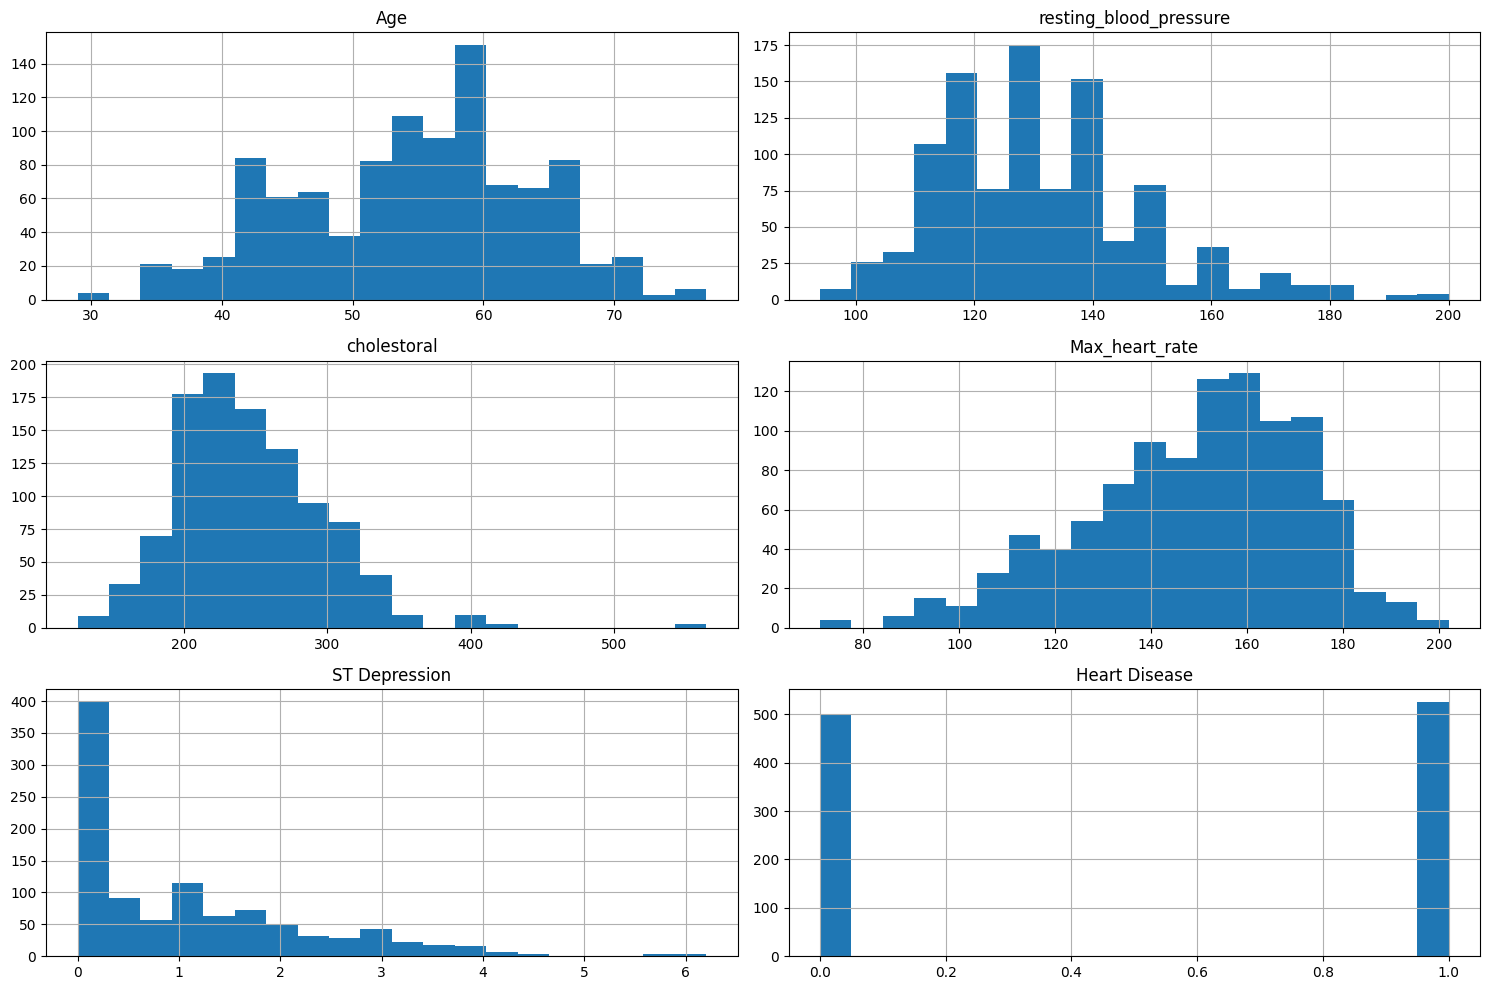

In [119]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()

<Axes: >

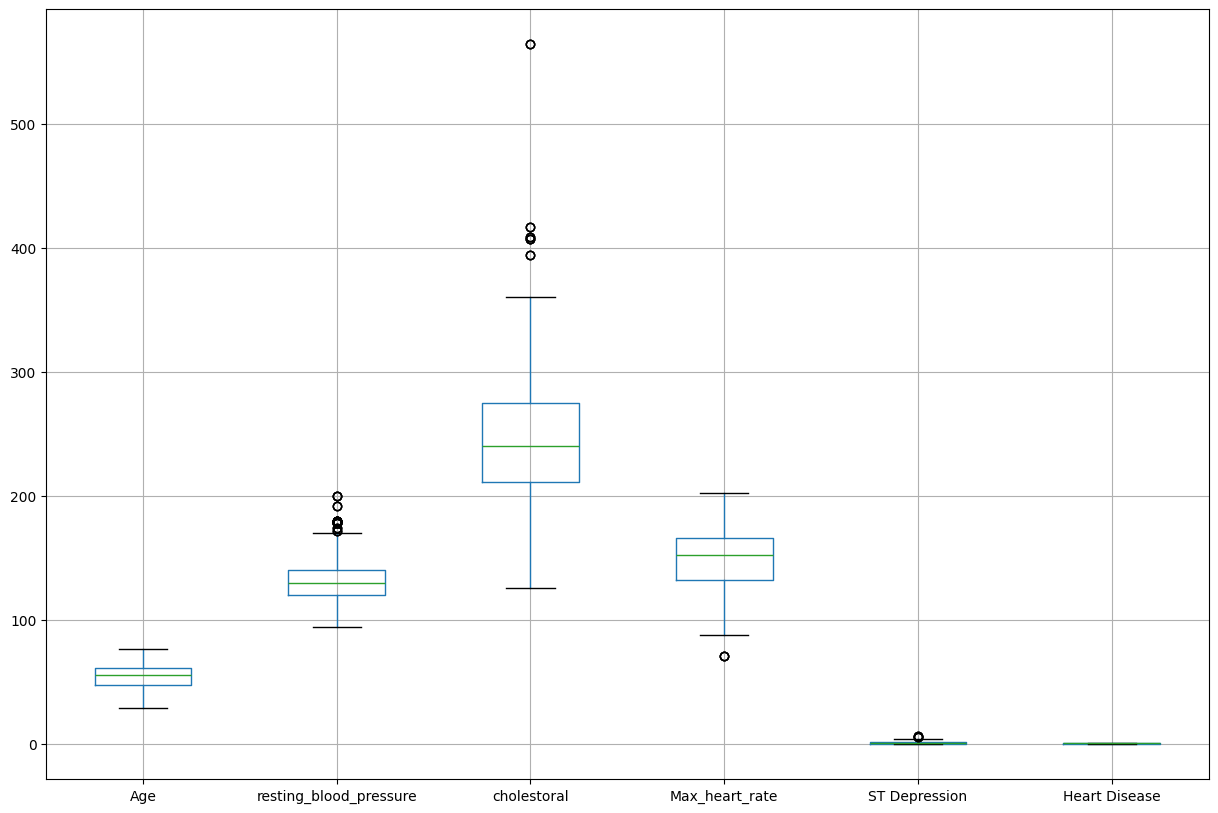

In [120]:
df.boxplot(figsize=(15,10))

Age has outliers: 0 rows
resting_blood_pressure has outliers: 30 rows
cholestoral has outliers: 16 rows
Max_heart_rate has outliers: 4 rows
ST Depression has outliers: 7 rows
Heart Disease has outliers: 0 rows


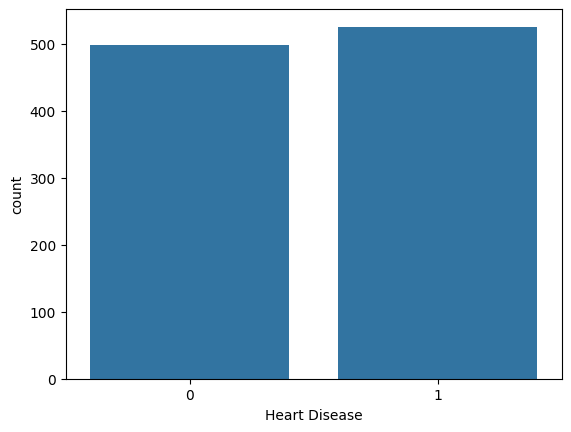

In [121]:
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col} has outliers: {outliers.shape[0]} rows')
seb.countplot(x='Heart Disease', data=df)
plt.show()

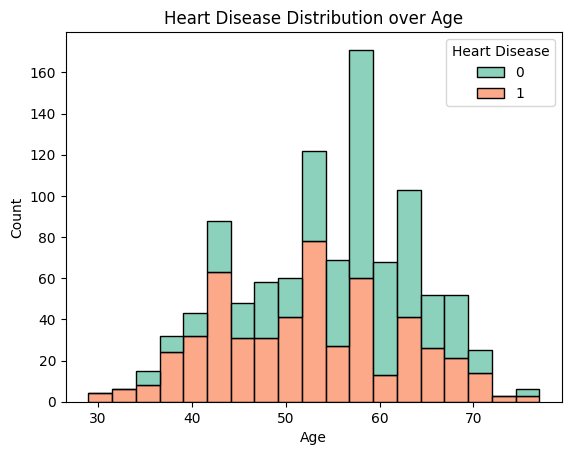

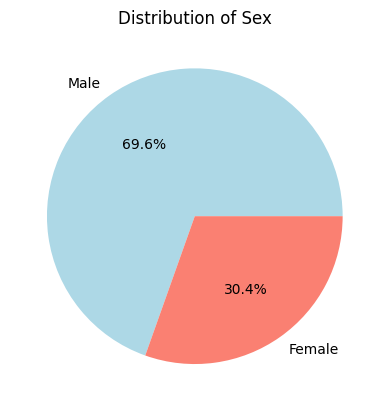

In [127]:
seb.histplot(data=df_copy, x='Age', hue='Heart Disease', multiple='stack', palette='Set2')
plt.title("Heart Disease Distribution over Age")
plt.show()

plt.pie(df['Sex'].value_counts(), labels=['Male', 'Female'], autopct="%1.1f%%", colors=['lightblue', 'salmon'])
plt.title("Distribution of Sex")
plt.show()

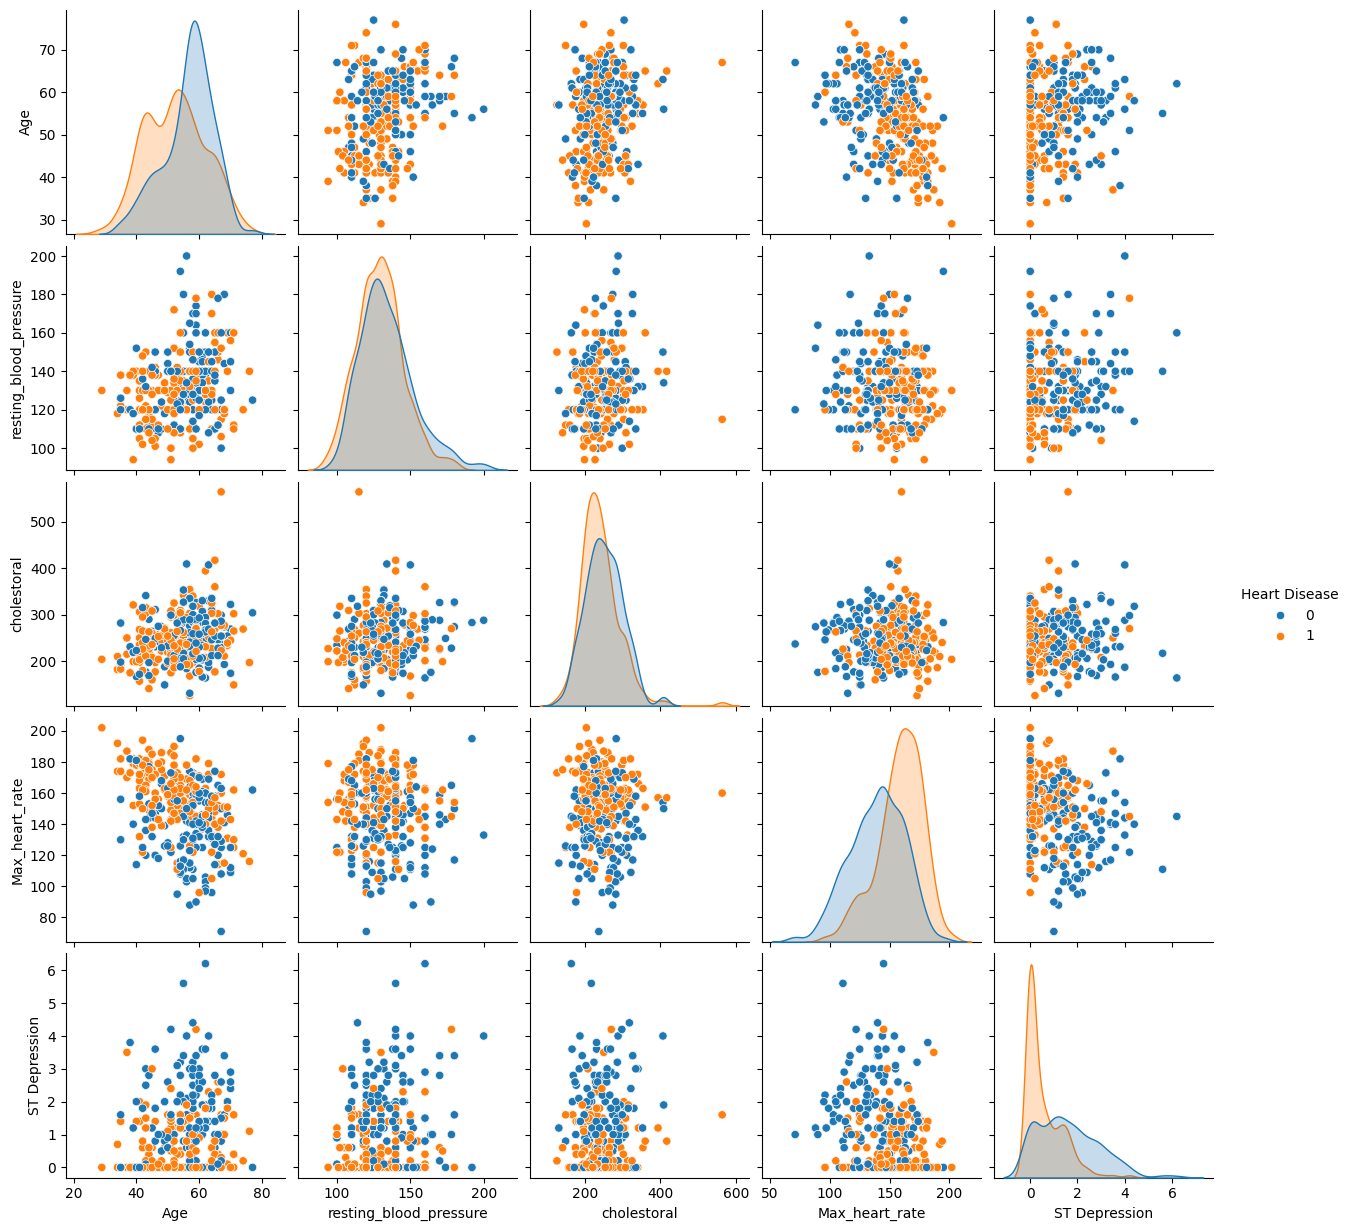

In [129]:
seb.pairplot(df_copy, hue='Heart Disease', diag_kind='kde')
plt.show()